# <span style="color:darkblue"> Lecture 8b: Multiprocessing </span>

# <span style="color:darkblue"> I. Before we start </span>

<font size = "5">

Follow these instructions:

<font size = "3">

Install the following packages in Anaconda.<br>
Open your operating system terminal and type the following:

``` conda install conda-forge::multiprocess  ``` <br>

In Windows you can also uses the Anaconda Prompt

<font size = "5">

Import relevant packages

In [1]:
import multiprocess as mp
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## <span style="color:darkblue"> II. Basics of multi-processing </span>

<font size = "5">

Count number of CPUs

In [2]:
num_cpus = mp.cpu_count()
print(num_cpus)

10


<font size = "5">

Define functions

In [3]:
fn_iseligible_vote = lambda age: age >= 18

<font size = "5">

Looping  + Functions


In [ ]:
list_ages = [18,29,15,32,6]

for age in list_ages:
    print(str(fn_iseligible_vote(age))) # Peter: why is "str" even here?


True
True
False
True
False


In [5]:
list_ages = [18,29,15,32,6]

for age in list_ages:
    print(fn_iseligible_vote(age))

True
True
False
True
False


<font size = "5">

Map  + Functions


In [6]:
list_ages = [18,29,15,32,6]
output = list(map(fn_iseligible_vote,list_ages))
output

[True, True, False, True, False]

<font size = "5">

Parallel Map + Functions

- Use the "pool" command to distribute computation across <br>
differen processors in the computer


In [7]:
help(mp.Pool)

Help on method Pool in module multiprocess.context:

Pool(processes=None, initializer=None, initargs=(), maxtasksperchild=None) method of multiprocess.context.DefaultContext instance
    Returns a process pool object



In [8]:
list_ages = [18,29,15,32,6]

with mp.Pool(num_cpus) as pool:
    output = pool.map(fn_iseligible_vote, list_ages)

output

[True, True, False, True, False]

## <span style="color:darkblue"> III. Other tricks </span>

<font size = "5">

Partialling out:
- Make functions only depend on one argument <br>
with the other fixed at a fixed value

In [9]:
help(int)

Help on class int in module builtins:

class int(object)
 |  int([x]) -> integer
 |  int(x, base=10) -> integer
 |
 |  Convert a number or string to an integer, or return 0 if no arguments
 |  are given.  If x is a number, return x.__int__().  For floating-point
 |  numbers, this truncates towards zero.
 |
 |  If x is not a number or if base is given, then x must be a string,
 |  bytes, or bytearray instance representing an integer literal in the
 |  given base.  The literal can be preceded by '+' or '-' and be surrounded
 |  by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
 |  Base 0 means to interpret the base from the string as an integer literal.
 |  >>> int('0b100', base=0)
 |  4
 |
 |  Built-in subclasses:
 |      bool
 |
 |  Methods defined here:
 |
 |  __abs__(self, /)
 |      abs(self)
 |
 |  __add__(self, value, /)
 |      Return self+value.
 |
 |  __and__(self, value, /)
 |      Return self&value.
 |
 |  __bool__(self, /)
 |      True if self else False


In [12]:
int('1001', base = 2)

9

In [13]:
import functools

fn_twoarguments = lambda x,y: x + y

fn_oneargument = functools.partial(fn_twoarguments, y=2)

# The other parameter is assiged at the previous predetermined value
fn_oneargument(x = 5)


7

In [14]:
help(functools.partial)

Help on class partial in module functools:

class partial(builtins.object)
 |  partial(func, /, *args, **keywords)
 |
 |  Create a new function with partial application of the given arguments
 |  and keywords.
 |
 |  Methods defined here:
 |
 |  __call__(self, /, *args, **kwargs)
 |      Call self as a function.
 |
 |  __delattr__(self, name, /)
 |      Implement delattr(self, name).
 |
 |  __get__(self, instance, owner=None, /)
 |      Return an attribute of instance, which is of type owner.
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __reduce__(self, /)
 |      Helper for pickle.
 |
 |  __repr__(self, /)
 |      Return repr(self).
 |
 |  __setattr__(self, name, value, /)
 |      Implement setattr(self, name, value).
 |
 |  __setstate__(self, object, /)
 |
 |  ----------------------------------------------------------------------
 |  Class methods defined here:
 |
 |  __class_getitem__(object, /)
 |      See PEP 585
 |
 |  ------------------------

<font size = "5">


Parallelizing functions with output of variable length


In [15]:
import multiprocess as mp

def bubble_sort(x):
    return np.array(x)*2

with mp.Pool(10) as pool:
    a = pool.map(bubble_sort, [[2,3,4],[1,9,4,5,2,6,8,4]])

print(a[0])
print(a[1])

[4 6 8]
[ 2 18  8 10  4 12 16  8]


<font size ="5">

Parallelizing functions with multiple output

In [ ]:
import multiprocess as mp

def bubble_sort(x):
    return pd.DataFrame({"x_bar":np.sum(x), "xsd" : np.std(x)}, index = [0])

with mp.Pool(10) as pool:
    a = pool.map(bubble_sort, [[2,3,4],[1,9,4,5,2,6,8,4]])

results_table = pd.concat(a)

In [22]:
print(a)

[   x_bar       xsd
0      9  0.816497,    x_bar      xsd
0     39  2.57087]


In [25]:
print(type(a[0]))
a[0]

<class 'pandas.core.frame.DataFrame'>


,x_bar,xsd
0,9,0.816497


In [26]:
print(type(a[1]))
a[1]

<class 'pandas.core.frame.DataFrame'>


,x_bar,xsd
0,39,2.57087


In [27]:
help(pd.concat)

Help on function concat in module pandas.core.reshape.concat:

concat(
    objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]',
    *,
    axis: 'Axis' = 0,
    join: 'str' = 'outer',
    ignore_index: 'bool' = False,
    keys: 'Iterable[Hashable] | None' = None,
    levels=None,
    names: 'list[HashableT] | None' = None,
    verify_integrity: 'bool' = False,
    sort: 'bool' = False,
    copy: 'bool | None' = None
) -> 'DataFrame | Series'
    Concatenate pandas objects along a particular axis.

    Allows optional set logic along the other axes.

    Can also add a layer of hierarchical indexing on the concatenation axis,
    which may be useful if the labels are the same (or overlapping) on
    the passed axis number.

    Parameters
    ----------
    objs : a sequence or mapping of Series or DataFrame objects
        If a mapping is passed, the sorted keys will be used as the `keys`
        argument, unless it is passed, in which case the values will be


In [21]:
results_table

,x_bar,xsd
0,9,0.816497
0,39,2.570870


## <span style="color:darkblue"> IV. Application: Running Simulations </span>

<font size = "5"> 

Simulation via for loops

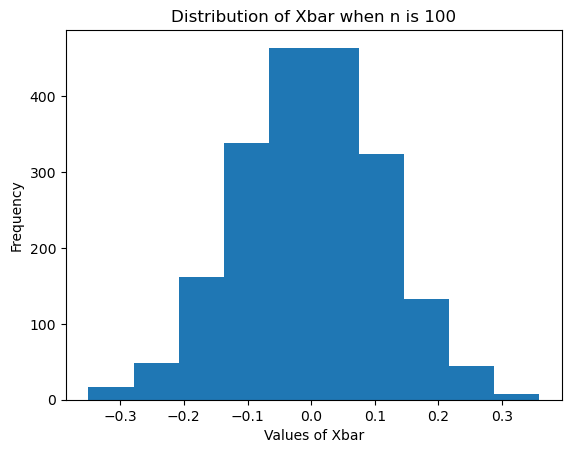

In [28]:
# To evaluate different sample size which just have to write a for-loop within 
# another for-loop

num_simulations = 2000
sample_size = 100

# The following command a vector null values, of length "num_simulations"
vec_xbar = [None] * num_simulations

for iteration in range(num_simulations):
        vec_unif  = np.random.uniform(low = -2, high=2, size = sample_size)
        vec_xbar[iteration] = vec_unif.mean()

plt.hist(vec_xbar)
plt.title("Distribution of Xbar when n is " + str(sample_size))
plt.ylabel("Frequency")
plt.xlabel("Values of Xbar")
plt.show()

    

<font size = "5">

Writing the main task as a function

In [29]:
# We define a function
# The iteration argument is not used in the body of the code
# and is only used to keep track of iterations for the parallel code later

def simulate_estimator(iteration):
    vec_unif  = np.random.uniform(low = -2, high=2, size = sample_size)
    xbar = vec_unif.mean()
    xsd  = vec_unif.std()
    return pd.DataFrame({"xbar":xbar, "xsd" : xsd}, index = [0])

# Rest that the function is running
simulate_estimator(0)

,xbar,xsd
0,0.080209,1.12247


In [30]:
simulate_estimator(1)

,xbar,xsd
0,0.062756,1.158412


<font size = "5"> 

Simulation via multiprocessing

In [31]:
with mp.Pool(num_cpus) as pool:
    vec_xbar = pool.map(simulate_estimator, range(num_simulations))

results_table = pd.concat(vec_xbar)

In [32]:
results_table

,xbar,xsd
0,0.046586,1.139383
0,0.044936,1.114367
0,0.038192,1.170645
0,-0.062934,1.163349
0,-0.080141,1.167388
...,...,...
0,0.138591,1.120546
0,-0.015004,1.070203
0,-0.028195,1.240345
0,-0.089654,1.115339


<font size ="5">

Try it yourself! Test whether this is a 95% confidence interval

Code the following exercise from Lecture 7 in parallel.


<font size = "3">

Procedure:
- Create a variable called "num_simulations" with value 1000
- Create the simulation parameters "n", "population_mean", "populations_stdv".
- Create an empty vector called "list_test_confidenceinterval".
- Create a loop. At each iteration:

    - Create a vector of normal random variables of size "n".
    - Create a variable "test_confidenceinterval", which tests:
    
        lower_bound $\quad \le \quad $ population_mean $\quad \le \quad$ upper_bound
    - Append "test_confidenceinterval" to the above list
    
- Compute the mean of "list_test_confidenceinterval"

Note: The final result should be close to 95%.



In [ ]:
# Write your own code



